# 96 · 원 실험의 저장 경계를 보존하는 건강점수와 급하락 알림

**목적:** 학습된 모델의 **원래 이상 점수 `score` + 저장된 임계값 + 비교 연산자**를 그대로 사용합니다. 95의 전체 윈도우 LOSS에 임계값 숫자만 옮기지 않습니다. `score`를 건강점수로 변환해도 원래 이상 판정과 F1이 동일한지 자동 검증합니다.

이 노트북은 원 실험의 저장 평가 결과를 분석합니다. 모델을 재학습·재추론하거나 Test로 기준을 선택하지 않습니다. **95 실행 없이 독립 실행**하며 원본 센서 CSV나 GPU는 필요하지 않습니다. 원 실행 폴더의 `config`, `selection`, `data_summary/window_manifest.csv`, Valid/Test 평가 폴더가 필요합니다.

**기본 선택:** 원 primary 체크포인트를 유지하며, 그 체크포인트에 저장된 `valid_max_f1`을 이상 기준으로 선택합니다. `normal_q99`는 원 실험의 주 평가 정책이었으며, 여기서는 더 낮은 경계를 **관찰**로 사용하는 별도의 표시 설계입니다. 두 정책의 원래 성능을 모두 제시합니다. F1이 가장 높았던 다른 epoch를 자동 선택하지 않습니다.

**실행:** 설정 셀의 `RUN_PATH` 확인 → 위에서 아래로 실행. 실행 시각별 출력 폴더를 생성하며 기존 결과와 95를 덮어쓰지 않습니다. 다른 체크포인트를 분석하려면 그 가중치로 평가한 Valid/Test 폴더를 함께 지정해야 하며, 혼용하면 중단합니다.

**중요:** 01 baseline raw의 `score`는 마지막 시점·3채널 평균 복원 제곱오차입니다. 학습 LOSS는 전체 윈도우 평균이므로 서로 다릅니다. score 정의는 저장된 센서 가중합과 재대조합니다. 건강점수는 상대 척도이며 고장 확률·손상률·잔여수명이 아닙니다.
**공개용 사용 안내:** 먼저 `RUN_PATH`에 본인의 학습 실행 폴더를 지정하세요. 이 저장소에는 원 실행 폴더·평가 CSV·인증 파일을 포함하지 않습니다. 로컬 또는 클라우드 Jupyter에서 해당 폴더를 접근할 수 있어야 하며, Python의 numpy·pandas·matplotlib·scikit-learn이 필요합니다. Colab에서는 실행 폴더를 업로드하거나 Drive를 연결한 후 경로를 지정합니다.

기존 출력은 예시 실행의 결과입니다. 경로를 새로 지정해 실행하면 선택한 실험의 결과로 갱신됩니다. [96 분석 보고서](96_health_scores_analysis_report.md)에서 방법과 결과 해석을 볼 수 있습니다. 공유 사본의 출력 텍스트에서는 개인 경로를 제거했으며 원본 분석과 수치 계산은 보존했습니다.


In [1]:
RUN_PATH = ''  # 분석할 학습 실행 폴더를 지정하세요. 저장된 config/selection/Valid/Test 평가 자료가 필요합니다.
VALID_EVALUATION = 'valid/final_evaluation'
TEST_EVALUATION = 'test/primary'
ANOMALY_POLICY = 'valid_max_f1'   # 저장된 F1 최적 임계값; 새로 최적화하지 않음
OBSERVE_POLICY = 'normal_q99'    # 저장된 더 낮은 경계; 없거나 이상 경계보다 높으면 중단
RUN_TEST = True
WRITE_OUTPUTS = True
OUTPUT_ROOT = ''                # 빈 값: RUN_DIR/threshold_health_analysis96/실행시각
EPSILON = 1e-12
RATE_CONFIG = dict(rate_seconds=1., rate_min_points=6, max_gap_seconds=.15,
                   rate_observe_tail=.05, rate_warning_tail=.01, rate_clear_tail=.05,
                   warning_consecutive=2, clear_consecutive=2, level_gate_tail=1.) # 현재 수준과 관계없이 급하락 판정 허용
# 위 시간/속도 규칙은 추가 탐색 정책입니다. 저장된 이상 판정이나 F1을 바꾸지 않습니다.

## 1. 원 실험과 평가 자료 검증

체크포인트 이름·epoch, 점수 정의, threshold/operator, 윈도우 ID·시간·라벨을 대조합니다. CSV는 `float_precision='round_trip'`으로 읽어 경계와 같은 점수의 `>=` 판정을 보존합니다. Valid에서 경계 선정 절차를 재계산하는 것은 **일치 검사**이며 실제 판정에는 저장된 값만 사용합니다.

In [2]:
import json, hashlib, platform
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
from IPython.display import display, Markdown

ALGORITHM_VERSION = 'saved_threshold_health_v1'
def locate_run(value):
    p = Path(value).expanduser()
    candidates = [p] if p.is_absolute() else [base/p for base in [Path.cwd(), *Path.cwd().parents]]
    found = list(dict.fromkeys(q.resolve() for q in candidates if (q/'selection/checkpoint_index.json').is_file()))
    if len(found)!=1: raise FileNotFoundError('RUN_PATH를 원 실험 폴더의 절대 경로로 지정하세요.')
    return found[0]

def read_json(p): return json.loads(Path(p).read_text(encoding='utf-8'))
def read_csv(p): return pd.read_csv(p, float_precision='round_trip')
def sha256(p): return hashlib.sha256(Path(p).read_bytes()).hexdigest()
def check(condition, message):
    if not condition: raise ValueError(message)
def predict_rule(values, rule):
    check(rule['operator'] in ('>', '>='), '지원하지 않는 비교 연산자')
    threshold = float(rule['threshold'])
    check(np.isfinite(threshold) and threshold >= 0, '유효하지 않은 경계')
    v = np.asarray(values, float)
    return v >= threshold if rule['operator']=='>=' else v > threshold

RUN_DIR = locate_run(RUN_PATH)
CONFIG = read_json(RUN_DIR/'config/experiment.json')
PRIMARY = read_json(RUN_DIR/'selection/primary.json')
INDEX = read_json(RUN_DIR/'selection/checkpoint_index.json')
POLICY_REGISTRY = read_json(RUN_DIR/'selection/checkpoint_policies.json')['checkpoints']
MANIFEST = read_csv(RUN_DIR/'data_summary/window_manifest.csv')
check(MANIFEST.window_id.is_unique, 'manifest 중복 ID')
INPUT_FILES = [RUN_DIR/p for p in ['config/experiment.json','selection/primary.json',
    'selection/checkpoint_index.json','selection/checkpoint_policies.json','data_summary/window_manifest.csv']]
EVAL_DIRS = {'valid': RUN_DIR/VALID_EVALUATION}
if RUN_TEST: EVAL_DIRS['test'] = RUN_DIR/TEST_EVALUATION
INFO = {}; DATA = {}; SAVED_METRICS = {}; SCORE_DEFINITIONS = {}
for split, folder in EVAL_DIRS.items():
    info = read_json(folder/'evaluation_info.json')
    check(info['split']==split and info['threshold_source']=='Valid', '평가 split/경계 출처 불일치')
    check(info.get('test_used_for_selection') is False, 'Test 선택 금지 메타데이터가 없습니다.')
    keys = [k for k,v in INDEX.items() if v['filename']==info['checkpoint'] and int(v['epoch'])==int(info['epoch'])]
    check(len(keys)==1 and keys[0] in POLICY_REGISTRY, '체크포인트에 연결된 정책을 찾을 수 없습니다.')
    entry = POLICY_REGISTRY[keys[0]]
    check(int(entry['epoch'])==int(info['epoch']), '정책 epoch 불일치')
    if split=='valid':
        CHECKPOINT_KEY = keys[0]; SELECTED_INFO = info
    else:
        check(keys[0]==CHECKPOINT_KEY and info['checkpoint']==SELECTED_INFO['checkpoint']
              and info['target']==SELECTED_INFO['target'], 'Valid/Test 체크포인트 또는 target 혼용')
    for name in [OBSERVE_POLICY, ANOMALY_POLICY]:
        check(name in info['policies'] and name in entry['policies'], '요청한 저장 정책이 없습니다: '+name)
        check(info['policies'][name]==entry['policies'][name], '선택 정책과 평가 정책 불일치: '+name)
        if split=='test': check(info['policies'][name]==SELECTED_INFO['policies'][name], 'Test 경계 변경 감지')
    df = read_csv(folder/'scores.csv')
    required = {'window_id','split','source','segment','input_end_time','score','label_current',info['target'],
                ANOMALY_POLICY+'_prediction', OBSERVE_POLICY+'_prediction'}
    check(required.issubset(df.columns) and df.window_id.is_unique, '점수 파일의 필수 열/ID 확인 필요')
    check(df.split.eq(split).all() and np.isfinite(df.score).all() and df.score.ge(0).all(), 'score/split 오류')
    expected = MANIFEST[MANIFEST.split.eq(split)].set_index('window_id')
    check(set(df.window_id)==set(expected.index), 'manifest와 평가 ID 불일치')
    for col in ['source','segment','label_current',info['target']]:
        check(np.array_equal(df[col].to_numpy(),expected.loc[df.window_id,col].to_numpy()), 'manifest 불일치: '+col)
    check(np.array_equal(pd.to_datetime(df.input_end_time,utc=True).to_numpy(),
                         pd.to_datetime(expected.loc[df.window_id,'input_end_time'],utc=True).to_numpy()), '시각 불일치')
    check(df.label_current.isin([0,1]).all() and df[info['target']].isin([0,1]).all(), '이진 라벨 필요')
    definition = read_json(folder/'score_definition.json')
    reconstructed = np.zeros(len(df))
    for sensor, weight in definition['sensor_weights'].items():
        check('score_'+sensor in df, '센서 점수 열 누락')
        reconstructed += float(weight)*df['score_'+sensor].to_numpy()
    check(np.allclose(reconstructed,df.score,rtol=2e-6,atol=1e-8), '원 score와 저장 센서 가중합 불일치')
    INFO[split]=info; DATA[split]=df; SCORE_DEFINITIONS[split]=definition
    SAVED_METRICS[split]=read_json(folder/'metrics.json')
    INPUT_FILES += [folder/p for p in ['evaluation_info.json','score_definition.json','scores.csv','metrics.json']]

RULES = {name:dict(SELECTED_INFO['policies'][name]) for name in [OBSERVE_POLICY,ANOMALY_POLICY]}
W = RULES[OBSERVE_POLICY]['threshold']; T = RULES[ANOMALY_POLICY]['threshold']
check(W<T, '관찰 경계가 이상 경계보다 낮아야 합니다. 경계를 임의로 만들지 않습니다.')
TARGET = SELECTED_INFO['target']
VALID = DATA['valid']
# Verify original baseline raw score definition as well as the generic sensor-weight check.
spec = CONFIG['spec']
if spec['family']=='baseline' and not spec.get('matched_loss',False):
    description = '마지막 시점·입력 채널 평균 복원 제곱오차 (전체 윈도우 LOSS와 다름)'
else:
    description = '원 실험 scores.csv의 score; 저장된 센서 가중합과 일치 확인'
display(pd.DataFrame([dict(checkpoint=SELECTED_INFO['checkpoint'], epoch=SELECTED_INFO['epoch'],
    logical_checkpoint=CHECKPOINT_KEY, score_definition=description, evaluation_target=TARGET,
    original_primary_checkpoint=PRIMARY['checkpoint'])]))
display(pd.DataFrame([dict(policy=k, threshold=v['threshold'], operator=v['operator'],
    role='이상 판정' if k==ANOMALY_POLICY else '관찰 진입') for k,v in RULES.items()]))

,checkpoint,epoch,logical_checkpoint,score_definition,evaluation_target,original_primary_checkpoint
0,best_normal_loss_epoch_0795.pt,795,best_normal_loss.pt,마지막 시점·입력 채널 평균 복원 제곱오차 (전체 윈도우 LOSS와 다름),label_10s,best_normal_loss_epoch_0795.pt


,policy,threshold,operator,role
0,normal_q99,0.222636,>,관찰 진입
1,valid_max_f1,0.337276,>=,이상 판정


## 2. 원래 임계값·판정·F1 재현

기존 `normal_q99`는 정상 Valid score의 Q99(`higher`)와 `>`를, `valid_max_f1`은 Valid PR 후보 중 F1 최대 경계와 `>=`를 사용했습니다. 최대 F1 동률이면 가장 높은 경계를 선택한 원 코드까지 대조합니다. **이상 F1은 `anomaly`만 양성**으로 계산합니다. 관찰 또는 급하락 알림까지 양성으로 합친 성능은 별도로 표기합니다.

In [3]:
def binary_metrics(y, prediction):
    y = np.asarray(y,int); pred=np.asarray(prediction,bool)
    tn,fp,fn,tp = metrics.confusion_matrix(y,pred,labels=[0,1]).ravel()
    return dict(TN=int(tn),FP=int(fp),FN=int(fn),TP=int(tp),
                precision=float(tp/(tp+fp)) if tp+fp else 0.,
                recall=float(tp/(tp+fn)) if tp+fn else 0.,
                F1=float(2*tp/(2*tp+fp+fn)) if 2*tp+fp+fn else 0.)

normal_reference = VALID.loc[VALID.label_current.eq(0),'score'].to_numpy()
check(len(normal_reference)>0 and VALID[TARGET].nunique()==2, '정상 기준과 Valid 두 클래스 필요')
recomputed = {'normal_q99': float(np.quantile(normal_reference,.99,method='higher'))}
pp,rr,tt = metrics.precision_recall_curve(VALID[TARGET], VALID.score)
ff = 2*pp[:-1]*rr[:-1]/np.maximum(pp[:-1]+rr[:-1],1e-30)
recomputed['valid_max_f1'] = float(tt[np.flatnonzero(np.isclose(ff,ff.max(),rtol=0,atol=1e-15))[-1]])
for name, value in recomputed.items():
    if name in RULES:
        check(value==RULES[name]['threshold'], '저장 임계값 선정 절차 재현 실패: '+name)
comparison=[]
for split, df in DATA.items():
    for name, rule in RULES.items():
        pred = predict_rule(df.score,rule)
        check(np.array_equal(pred,df[name+'_prediction'].to_numpy()), '원 예측 불일치: '+split+'/'+name)
        for target in dict.fromkeys([TARGET,'label_current']):
            result = binary_metrics(df[target],pred)
            saved = SAVED_METRICS[split][target+'__'+name]
            for key,value in result.items():
                check(np.isclose(value,saved[key],rtol=0,atol=1e-12), '원 지표 불일치: '+split+'/'+name+'/'+key)
            comparison.append(dict(split=split,target=target,policy=name,**result,saved_F1=saved['F1'],
                                   prediction_mismatches=0,F1_difference=result['F1']-saved['F1']))
REPRODUCTION = pd.DataFrame(comparison)
display(REPRODUCTION)
print('저장 경계·연산자·원 예측·혼동행렬·F1 일치 확인 완료. 새 경계를 선택하지 않았습니다.')

,split,target,policy,TN,FP,FN,TP,precision,recall,F1,saved_F1,prediction_mismatches,F1_difference
0,valid,label_10s,normal_q99,976,9,7,95,0.913462,0.931373,0.922330,0.922330,0,0.0
1,valid,label_current,normal_q99,976,9,7,95,0.913462,0.931373,0.922330,0.922330,0,0.0
2,valid,label_10s,valid_max_f1,984,1,9,93,0.989362,0.911765,0.948980,0.948980,0,0.0
3,valid,label_current,valid_max_f1,984,1,9,93,0.989362,0.911765,0.948980,0.948980,0,0.0
4,test,label_10s,normal_q99,1965,23,8,166,0.878307,0.954023,0.914601,0.914601,0,0.0
5,test,label_current,normal_q99,1965,23,8,166,0.878307,0.954023,0.914601,0.914601,0,0.0
6,test,label_10s,valid_max_f1,1979,9,13,161,0.947059,0.925287,0.936047,0.936047,0,0.0
7,test,label_current,valid_max_f1,1979,9,13,161,0.947059,0.925287,0.936047,0.936047,0,0.0


저장 경계·연산자·원 예측·혼동행렬·F1 일치 확인 완료. 새 경계를 선택하지 않았습니다.


## 3. 경계를 건강점수로 환산하고 정수 범위로 안내

`x=log10(score+epsilon)`, `H=100×(b−x)/(b−a)`. `a,b`는 Valid 전체 score의 로그 최소·최대입니다. 감소하는 단조 변환이므로 `score≥T`는 원 건강점수 `H≤H(T)`, `score>T`는 `H<H(T)`에 대응합니다. 실제 판정은 부동소수점 환산 오차·반올림·clipping 영향을 피하기 위해 **원 score에서 수행**합니다.

`normal_q99 < valid_max_f1`일 때 정상 / 관찰 / 이상으로 나누는 것은 두 기존 정책을 활용한 프로젝트 표시 설계입니다. 논문이 이 조합이나 세 고장 단계를 검증한 것은 아닙니다. 건강점수는 새로운 예측 정보를 만들지 않습니다.

사용자 점수는 정수로 반올림한 뒤 원래 판정된 상태 범위 안에 제한합니다. 따라서 경계 부근에서 정수 점수와 상태가 모순되지 않습니다. 원점수·원 경계·연산자는 별도 보존합니다.

In [4]:
def ordered_hi_traces(frame, config):
    """Input trace boundaries must already separate gaps; never join invalid timestamps."""
    for trace_id, g in frame.groupby('trace_id', sort=False):
        g = g.assign(_t=pd.to_datetime(g.input_end_time, utc=True, errors='raise')).sort_values('_t')
        if g._t.isna().any() or g._t.duplicated().any():
            raise ValueError('Missing/duplicate timestamps in HI trace.')
        if g._t.diff().dt.total_seconds().gt(config['max_gap_seconds'] + 1e-9).any():
            raise ValueError('Gap inside trace_id: split the observation traces.')
        yield trace_id, g

def exact_tail_boundary(reference, alpha, positive_only=False):
    """For finite v: empirical_tail(v, ref) <= alpha iff v > boundary (ties included)."""
    ref = np.sort(np.asarray(reference, float))
    if not 0 < alpha < 1 or not np.isfinite(ref).all():
        raise ValueError('Invalid empirical-tail reference or alpha.')
    unique = np.unique(ref)
    right_tail = (1 + len(ref) - np.searchsorted(ref, unique, side='right')) / (len(ref) + 1)
    eligible = np.flatnonzero(right_tail <= alpha)
    if not len(eligible):
        return dict(status='unreachable_reference_resolution', tail_level=alpha,
                    reference_n=len(ref), boundary=None, tail_boundary=None, operator='>')
    value = float(unique[eligible[0]])
    return dict(status='available', tail_level=alpha, reference_n=len(ref),
                tail_boundary=value, boundary=max(0., value) if positive_only else value,
                operator='>', positive_only=positive_only)

def apply_hi_rate_policy(frame, config):
    """Level state and independent, causal rate alarm. Notifications occur only on entry."""
    out = frame.copy()
    p, pr = out.normal_tail_fraction, out.rate_tail_fraction
    out['rate_available'] = np.isfinite(out.hi_drop_rate) & np.isfinite(pr)
    positive = out.rate_available & out.hi_drop_rate.gt(0)
    out['steep_drop'] = positive & pr.le(config['rate_warning_tail'])
    out['falling'] = positive & pr.le(config['rate_observe_tail'])
    out['rate_level_gate'] = p.le(config['level_gate_tail'])
    out['trend_attention'] = out.falling & out.rate_level_gate
    out['warning_candidate'] = out.steep_drop & out.rate_level_gate
    # State depends only on current level. Anomaly never masks a rate alarm.
    anomaly = out.anomaly_prediction.astype(bool)
    near = out.observe_prediction.astype(bool)
    out['hi_stage'] = np.select([anomaly, near], ['anomaly', 'observe'], default='normal')
    out['hi_reason'] = np.select([anomaly, near], ['level_anomaly', 'near_boundary'], default='no_level_trigger')
    out['rate_status'] = np.where(out.rate_available, 'evaluated', 'insufficient_history')
    for name in ['steep_sustained', 'warning_active', 'warning_notify', 'warning_cleared', 'warning_clear_pending']:
        out[name] = False
    out['warning_clear_reason'] = ''
    for _, g in ordered_hi_traces(out, config):
        active = False
        entry_run = exit_run = steep_run = 0
        for idx, row in g.iterrows():
            if not row.rate_available:
                if active:
                    out.loc[idx, ['warning_cleared', 'warning_clear_reason']] = [True, 'insufficient_history']
                active = False
                entry_run = exit_run = steep_run = 0
                continue
            steep_run = steep_run + 1 if row.steep_drop else 0
            out.loc[idx, 'steep_sustained'] = steep_run >= config['warning_consecutive']
            if not active:
                entry_run = entry_run + 1 if row.warning_candidate else 0
                if entry_run >= config['warning_consecutive']:
                    active = True
                    out.loc[idx, 'warning_notify'] = True
                    entry_run = 0
            else:
                # Hysteresis: entry tail .01, release tail > .05; recovery/gate exit also release.
                release = (row.hi_drop_rate <= 0 or row.rate_tail_fraction > config['rate_clear_tail']
                           or not row.rate_level_gate)
                exit_run = exit_run + 1 if release else 0
                if exit_run >= config['clear_consecutive']:
                    active = False
                    out.loc[idx, ['warning_cleared', 'warning_clear_reason']] = [True, 'release_confirmed']
                    entry_run = exit_run = 0
                elif release:
                    out.loc[idx, 'warning_clear_pending'] = True
            out.loc[idx, 'warning_active'] = active
    out['warning_phase'] = np.select(
        [out.warning_notify, out.warning_clear_pending, out.warning_active, out.warning_cleared, ~out.rate_available],
        ['started', 'clear_pending', 'ongoing', 'cleared', 'unavailable'], default='inactive')
    return out

def hi_warning_events(frame, config):
    """One row per notification. A trace ending is censored, not evidence of recovery."""
    rows = []
    for trace_id, g in ordered_hi_traces(frame, config):
        event = None
        for _, row in g.iterrows():
            if row.warning_notify:
                event = dict(trace_id=trace_id, split=row.split, label=int(row.label_current),
                             start_time=row._t, active_windows=0, peak_drop_rate=float(row.hi_drop_rate))
            if event is not None and row.warning_active:
                event['active_windows'] += 1
                event['peak_drop_rate'] = max(event['peak_drop_rate'], float(row.hi_drop_rate))
            if event is not None and row.warning_cleared:
                rows.append(dict(event, end_time=row._t,
                                 observed_span_seconds=(row._t-event['start_time']).total_seconds(),
                                 end_reason=row.warning_clear_reason, right_censored=False))
                event = None
        if event is not None:
            end = g._t.iloc[-1]
            rows.append(dict(event, end_time=end, observed_span_seconds=(end-event['start_time']).total_seconds(),
                             end_reason='trace_end', right_censored=True))
    return pd.DataFrame(rows, columns=['trace_id','split','label','start_time','end_time','active_windows',
                                      'peak_drop_rate','observed_span_seconds','end_reason','right_censored'])

def theil_sen_slope(t, y):
    i, j = np.triu_indices(len(t), 1)
    return float(np.median((y[j] - y[i]) / (t[j] - t[i])))

def causal_hi_drop_rate(frame, config):
    """최근 rate_seconds의 과거·현재 HI만 사용한 Theil–Sen 기울기의 부호 반전(점/초, 양수 = 건강 하락)."""
    out = pd.Series(np.nan, index=frame.index, dtype=float)
    for _, g in ordered_hi_traces(frame, config):
        s = (g._t - g._t.iloc[0]).dt.total_seconds().to_numpy(); y = g.health_unclipped.to_numpy()
        for j, idx in enumerate(g.index):
            left = int(np.searchsorted(s, s[j] - config['rate_seconds'] - 1e-9))
            if j + 1 - left < config['rate_min_points'] or s[j] - s[left] < config['rate_seconds'] - 1e-8:
                continue
            out[idx] = -theil_sen_slope(s[left:j+1], y[left:j+1])
    return out

def empirical_tail(values, reference):
    """(1 + 기준 중 현재 값 이상 개수)/(N + 1). 기울기를 계산할 수 없는 윈도우는 결측으로 둡니다."""
    reference = np.sort(np.asarray(reference, float)); values = np.asarray(values, float)
    out = np.full(len(values), np.nan); ok = np.isfinite(values)
    out[ok] = (1 + len(reference) - np.searchsorted(reference, values[ok], side='left')) / (len(reference) + 1)
    return out

def hi_integer_display_spec(bounds):
    """Integer presentation bands only; empirical-tail decisions remain unchanged."""
    lower, upper = bounds['anomaly'], bounds['observe']
    if not np.isfinite([lower, upper]).all() or lower >= upper:
        raise ValueError('Ordered finite HI level boundaries required for integer presentation.')
    # Reserve at least one integer for each of the three states.
    observe_min = int(np.clip(np.ceil(lower), 1, 99))
    normal_min = int(np.clip(max(np.ceil(upper), observe_min + 1), 2, 100))
    ranges = {'normal': [normal_min, 100], 'observe': [observe_min, normal_min - 1],
              'anomaly': [0, observe_min - 1]}
    return dict(ranges=ranges, normal_min=normal_min, observe_min=observe_min,
                boundary_rounding='ceil; reserve at least one integer per state',
                score_rounding='nearest integer (half up), clamped within the already decided state band',
                decision_source='original unrounded empirical level tail; never classify using rounded HI')

def integer_hi_scores(frame, spec):
    """Avoid displaying e.g. 75/normal-range for an observe decision near the boundary."""
    raw = np.asarray(frame.health_index, float)
    if not np.isfinite(raw).all():
        raise ValueError('Nonfinite HI cannot be displayed as an integer.')
    rounded = np.floor(np.clip(raw, 0, 100) + .5).astype(int)
    result = pd.Series(rounded, index=frame.index, dtype='int64')
    if not frame.hi_stage.isin(spec['ranges']).all():
        raise ValueError('Unknown level state for integer display.')
    for stage, (lo, hi) in spec['ranges'].items():
        mask = frame.hi_stage.eq(stage)
        result.loc[mask] = result.loc[mask].clip(lo, hi)
    return result

In [5]:
def health_from_score(values, a, b):
    check(np.isfinite([a,b]).all() and b>a, '건강점수 범위가 퇴화했습니다.')
    v=np.asarray(values,float)
    check(np.isfinite(v).all() and (v>=0).all(), '유한한 비음수 score 필요')
    return 100*(b-np.log10(v+EPSILON))/(b-a)

LOG_MIN,LOG_MAX = np.log10(VALID.score+EPSILON).agg(['min','max'])
HI_SCALE = 100/(LOG_MAX-LOG_MIN)
HEALTH_BOUNDS = {'observe':float(health_from_score(W,LOG_MIN,LOG_MAX)),
                 'anomaly':float(health_from_score(T,LOG_MIN,LOG_MAX))}
INTEGER_SPEC = hi_integer_display_spec(HEALTH_BOUNDS)
WINDOWS = pd.concat(DATA.values(),ignore_index=True)
WINDOWS['health_unclipped'] = health_from_score(WINDOWS.score,LOG_MIN,LOG_MAX)
WINDOWS['health_index'] = WINDOWS.health_unclipped.clip(0,100)
WINDOWS['anomaly_prediction'] = predict_rule(WINDOWS.score,RULES[ANOMALY_POLICY])
WINDOWS['observe_prediction'] = predict_rule(WINDOWS.score,RULES[OBSERVE_POLICY])
WINDOWS['hi_stage'] = np.select([WINDOWS.anomaly_prediction,WINDOWS.observe_prediction],['anomaly','observe'],default='normal')
WINDOWS['hi_display_integer'] = integer_hi_scores(WINDOWS,INTEGER_SPEC)
DISPLAY_RANGES = pd.DataFrame([dict(state=s,state_name={'normal':'정상','observe':'관찰','anomaly':'이상'}[s],
    minimum=lo,maximum=hi,user_range=f'{lo}~{hi}점') for s,(lo,hi) in INTEGER_SPEC['ranges'].items()])
BOUNDARY_TABLE = pd.DataFrame([dict(role=role,policy=name,score_threshold=RULES[name]['threshold'],
    score_operator=RULES[name]['operator'], health_boundary=HEALTH_BOUNDS[role],
    health_operator='<=' if RULES[name]['operator']=='>=' else '<')
    for role,name in [('observe',OBSERVE_POLICY),('anomaly',ANOMALY_POLICY)]])
print('사용자 안내용 정수 범위');display(DISPLAY_RANGES[['state_name','user_range']])
print('분석용 정확한 경계 (표시 반올림으로 재판정하지 않음)');display(BOUNDARY_TABLE)
display(pd.DataFrame([dict(anchor='100점',valid_score=float(10**LOG_MIN-EPSILON)),
                      dict(anchor='0점',valid_score=float(10**LOG_MAX-EPSILON))]))

사용자 안내용 정수 범위


,state_name,user_range
0,정상,46~100점
1,관찰,43~45점
2,이상,0~42점


분석용 정확한 경계 (표시 반올림으로 재판정하지 않음)


,role,policy,score_threshold,score_operator,health_boundary,health_operator
0,observe,normal_q99,0.222636,>,45.290478,<
1,anomaly,valid_max_f1,0.337276,>=,42.348665,<=


,anchor,valid_score
0,100점,0.000098
1,0점,133.281387


## 4. 급하락 알림은 별도 감시

현재 상태와 F1은 위 저장 score 정책으로 고정합니다. **급하락 경계는 원 학습에서 찾은 값이 아닙니다.** 정상 Valid의 건강 하락 속도 분포로 따로 보정하는 탐색적 부가 규칙입니다. 마지막 시점 score는 전체 윈도우 LOSS보다 변동성이 클 수 있으므로 95의 속도 경계 숫자를 재사용하지 않습니다.

같은 연속 구간에서 최근 1초 전체·최소 6개 관측의 Theil–Sen 기울기를 구합니다. 양의 건강 하락 속도, 속도 tail≤1%, score 수준 tail≤0.5가 2회 연속이면 진입합니다. 속도 tail>5% 또는 회복 또는 수준 gate 이탈이 2회 연속이면 해제합니다. 정상/관찰/이상과 독립이며, 신규 알림은 진입 시 한 번만 발생합니다. 이력 부족·구간 변경은 초기화하고, 관측 종료 시 유지된 사건은 회복으로 간주하지 않습니다.

현재 데이터는 정상과 이상이 별도 날짜·구간이며 정상→고장 전이가 없습니다. 고장 전조·10초 선행 경고를 검증한 결과로 보고하지 않습니다. 연속 2회는 독립적인 두 증거가 아니며, 1%/5%도 운영 오경보 확률 보장이 아닙니다.

In [6]:
check(0<RATE_CONFIG['rate_warning_tail']<RATE_CONFIG['rate_observe_tail']<1, '속도 tail 설정 확인')
check(RATE_CONFIG['rate_warning_tail']<RATE_CONFIG['rate_clear_tail']<1, '해제 tail 설정 확인')
check(0<RATE_CONFIG['level_gate_tail']<=1 and RATE_CONFIG['rate_seconds']>0 and RATE_CONFIG['rate_min_points']>=2, '속도 설정 확인')
for key in ['warning_consecutive','clear_consecutive']:
    check(RATE_CONFIG[key]>=1 and RATE_CONFIG[key]==int(RATE_CONFIG[key]), '연속 횟수는 양의 정수')
WINDOWS['trace_id']=''
for (split,source,segment),g in WINDOWS.groupby(['split','source','segment'],sort=False):
    g=g.assign(_t=pd.to_datetime(g.input_end_time,utc=True,errors='raise')).sort_values('_t')
    check(g._t.notna().all() and not g._t.duplicated().any(), '중복/누락 시각')
    block=g._t.diff().dt.total_seconds().gt(RATE_CONFIG['max_gap_seconds']+1e-9).cumsum()
    WINDOWS.loc[g.index,'trace_id']=[f'{split}:{source}:{segment}:{b}' for b in block]
WINDOWS['normal_tail_fraction']=empirical_tail(WINDOWS.score,normal_reference) # rate gate only
WINDOWS['hi_drop_rate']=causal_hi_drop_rate(WINDOWS,RATE_CONFIG)
rate_reference=WINDOWS.loc[WINDOWS.split.eq('valid')&WINDOWS.label_current.eq(0),'hi_drop_rate'].dropna().to_numpy()
RATE_BOUNDARIES={name:exact_tail_boundary(rate_reference,alpha,positive_only=True) for name,alpha in
    [('observe',RATE_CONFIG['rate_observe_tail']),('warning',RATE_CONFIG['rate_warning_tail']),('clear',RATE_CONFIG['rate_clear_tail'])]}
RATE_AVAILABLE=all(rule['status']=='available' for rule in RATE_BOUNDARIES.values())
WINDOWS['rate_tail_fraction']=empirical_tail(WINDOWS.hi_drop_rate,rate_reference) if RATE_AVAILABLE else np.nan
before=WINDOWS.hi_stage.copy()
WINDOWS=apply_hi_rate_policy(WINDOWS,RATE_CONFIG)
check(np.array_equal(before,WINDOWS.hi_stage), '부가 속도 정책이 원 상태 판정을 변경했습니다.')
if not RATE_AVAILABLE:
    WINDOWS['rate_status']='reference_unavailable'
    print('정상 속도 기준 표본 부족: 급하락 알림은 비활성, 저장 경계의 상태 판정은 계속 사용합니다.')
EVENTS=hi_warning_events(WINDOWS,RATE_CONFIG)
def user_readout(row):
    names={'normal':'정상','observe':'관찰','anomaly':'이상'}
    lo,hi=INTEGER_SPEC['ranges'][row.hi_stage]
    text=f'건강 {int(row.hi_display_integer)}점 | {names[row.hi_stage]} ({lo}~{hi}점)'
    if row.warning_active: text+=' | 급하락 경고'+('(새 알림)' if row.warning_notify else '(해제 확인 중)' if row.warning_clear_pending else '(유지)')
    elif row.trend_attention: text+=' | 하락 추세 관찰'
    if row.rate_status=='evaluated':
        speed=abs(row.hi_drop_rate); direction='하락' if row.hi_drop_rate>0 else '회복' if row.hi_drop_rate<0 else '변화'
        speed_text='1점/초 미만' if 0<speed<.5 else f'약 {int(np.floor(speed+.5))}점/초'
        text+=f' | {direction} 속도 {speed_text}'
    else: text+=' | 속도: '+('기준 부족' if row.rate_status=='reference_unavailable' else '이력 부족')
    return text

WINDOWS['user_readout']=WINDOWS.apply(user_readout,axis=1)
ALARM_SUMMARY=WINDOWS.groupby(['split','label_current']).agg(windows=('window_id','size'),
    traces=('trace_id','nunique'),rate_coverage=('rate_available','mean'),
    notifications=('warning_notify','sum'),active_windows=('warning_active','sum'),clears=('warning_cleared','sum')).reset_index()
STATE_SUMMARY=WINDOWS.groupby(['split','label_current','hi_stage']).size().rename('windows').reset_index()
display(pd.DataFrame(RATE_BOUNDARIES).T)
display(STATE_SUMMARY);display(ALARM_SUMMARY)
examples=pd.concat([WINDOWS.groupby(['split','hi_stage'],sort=False).head(1),
                    WINDOWS[WINDOWS.warning_notify].groupby(['split','label_current'],sort=False).head(1)]).drop_duplicates('window_id')
display(examples[['split','window_id','user_readout']])

# F1 preservation is checked again after health display and rate processing.
health_metrics=[]
for split,g in WINDOWS.groupby('split'):
    saved=SAVED_METRICS[split][TARGET+'__'+ANOMALY_POLICY]
    original=binary_metrics(g[TARGET],g.hi_stage.eq('anomaly'))
    check(np.isclose(original['F1'],saved['F1'],atol=1e-12,rtol=0), '변환 후 F1 불일치')
    for name,pred in [('anomaly_only_original_policy',g.hi_stage.eq('anomaly')),
                      ('observe_or_anomaly_different_policy',g.hi_stage.ne('normal')),
                      ('anomaly_or_rate_alarm_different_policy',g.hi_stage.eq('anomaly')|g.warning_active)]:
        health_metrics.append(dict(split=split,target=TARGET,evaluation=name,**binary_metrics(g[TARGET],pred)))
HEALTH_METRICS=pd.DataFrame(health_metrics)
display(HEALTH_METRICS)

,status,tail_level,reference_n,tail_boundary,boundary,operator,positive_only
observe,available,0.05,573,13.257351,13.257351,>,True
warning,available,0.01,573,19.478817,19.478817,>,True
clear,available,0.05,573,13.257351,13.257351,>,True


,split,label_current,hi_stage,windows
0,test,0,anomaly,9
1,test,0,normal,1965
2,test,0,observe,14
3,test,1,anomaly,161
4,test,1,normal,8
5,test,1,observe,5
6,valid,0,anomaly,1
7,valid,0,normal,976
8,valid,0,observe,8
9,valid,1,anomaly,93


,split,label_current,windows,traces,rate_coverage,notifications,active_windows,clears
0,test,0,1988,90,0.587525,2,3,1
1,test,1,174,9,0.540230,2,12,1
2,valid,0,985,46,0.581726,1,5,1
3,valid,1,102,4,0.607843,1,8,1


,split,window_id,user_readout
0,valid,normal:424:14024:14043,건강 76점 | 정상 (46~100점) | 속도: 이력 부족
261,valid,normal:440:14564:14583,건강 45점 | 관찰 (43~45점) | 속도: 이력 부족
833,valid,normal:475:15730:15749,건강 39점 | 이상 (0~42점) | 속도: 이력 부족
1087,test,normal:482:16010:16029,건강 66점 | 정상 (46~100점) | 속도: 이력 부족
1215,test,normal:487:16233:16252,건강 45점 | 관찰 (43~45점) | 속도: 이력 부족
2572,test,normal:570:18980:18999,건강 40점 | 이상 (0~42점) | 속도: 이력 부족
625,valid,normal:462:15294:15313,건강 47점 | 정상 (46~100점) | 급하락 경고(새 알림) | 하락 속도 약...
1070,valid,anomaly:7:167:186,건강 0점 | 이상 (0~42점) | 급하락 경고(새 알림) | 하락 속도 약 38점/초
1342,test,normal:494:16482:16501,건강 53점 | 정상 (46~100점) | 급하락 경고(새 알림) | 하락 속도 약...
3128,test,anomaly:12:306:325,건강 20점 | 이상 (0~42점) | 급하락 경고(새 알림) | 하락 속도 약 2...


,split,target,evaluation,TN,FP,FN,TP,precision,recall,F1
0,test,label_10s,anomaly_only_original_policy,1979,9,13,161,0.947059,0.925287,0.936047
1,test,label_10s,observe_or_anomaly_different_policy,1965,23,8,166,0.878307,0.954023,0.914601
2,test,label_10s,anomaly_or_rate_alarm_different_policy,1976,12,13,161,0.930636,0.925287,0.927954
3,valid,label_10s,anomaly_only_original_policy,984,1,9,93,0.989362,0.911765,0.948980
4,valid,label_10s,observe_or_anomaly_different_policy,976,9,7,95,0.913462,0.931373,0.922330
5,valid,label_10s,anomaly_or_rate_alarm_different_policy,979,6,9,93,0.939394,0.911765,0.925373


## 5. 원 점수·경계·건강점수·시간 추세 시각화

원 score 경계와 건강점수 경계를 모두 표시합니다. 정수 건강점수는 사용자 안내에, 원점수와 소수점 경계는 분석에 사용합니다. 각 관측 구간은 따로 그리며 다른 날짜를 연결하지 않습니다.

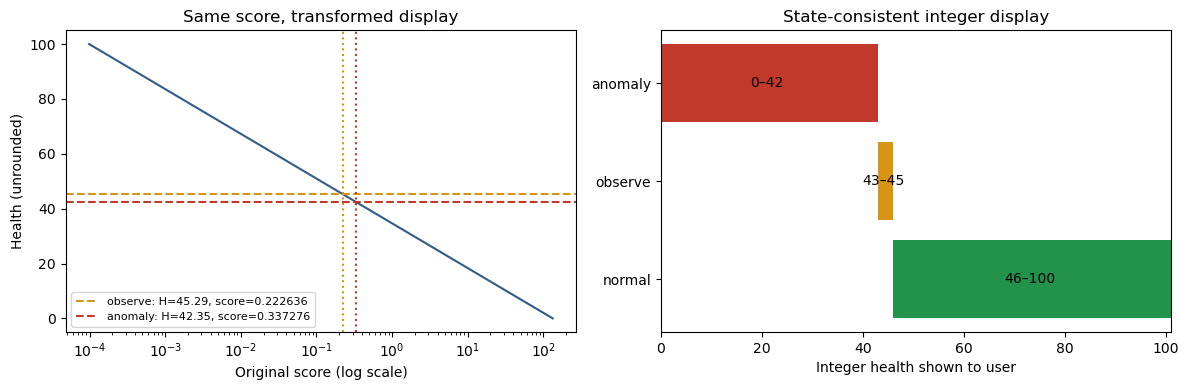

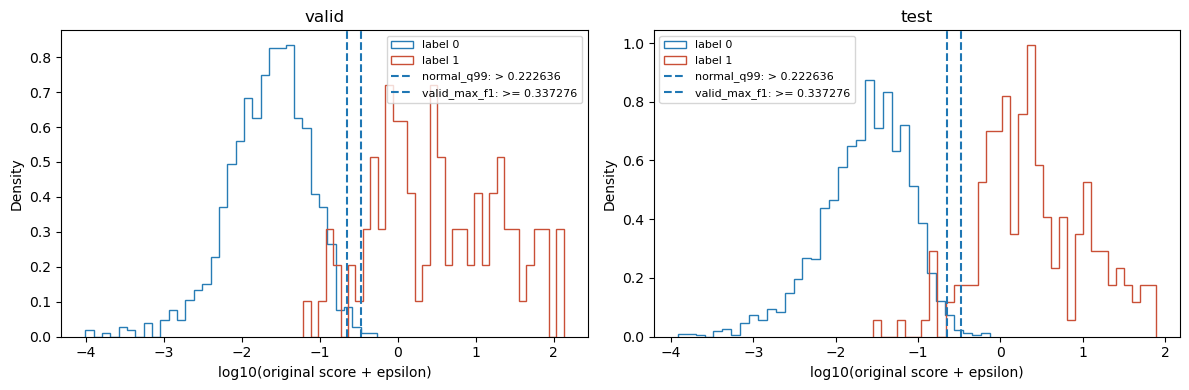

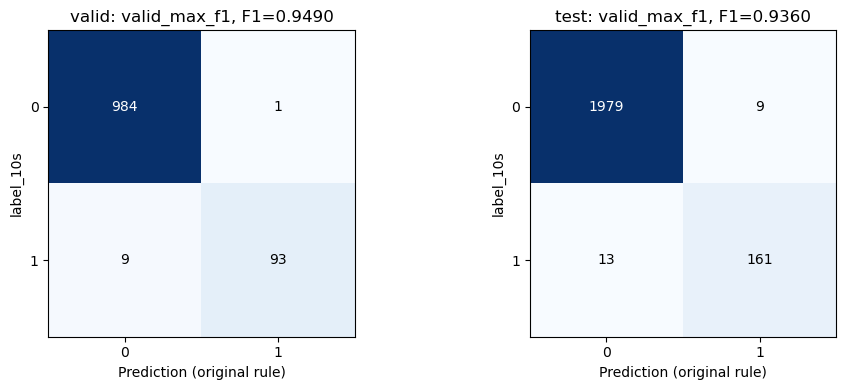

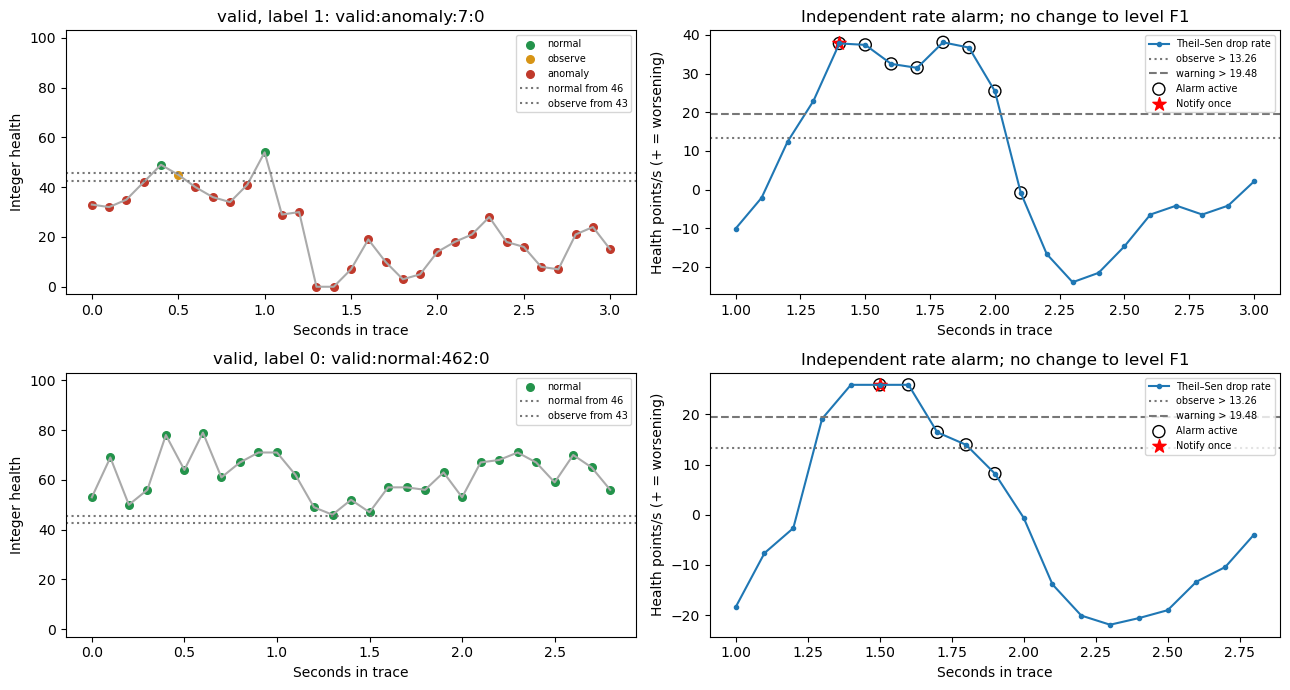

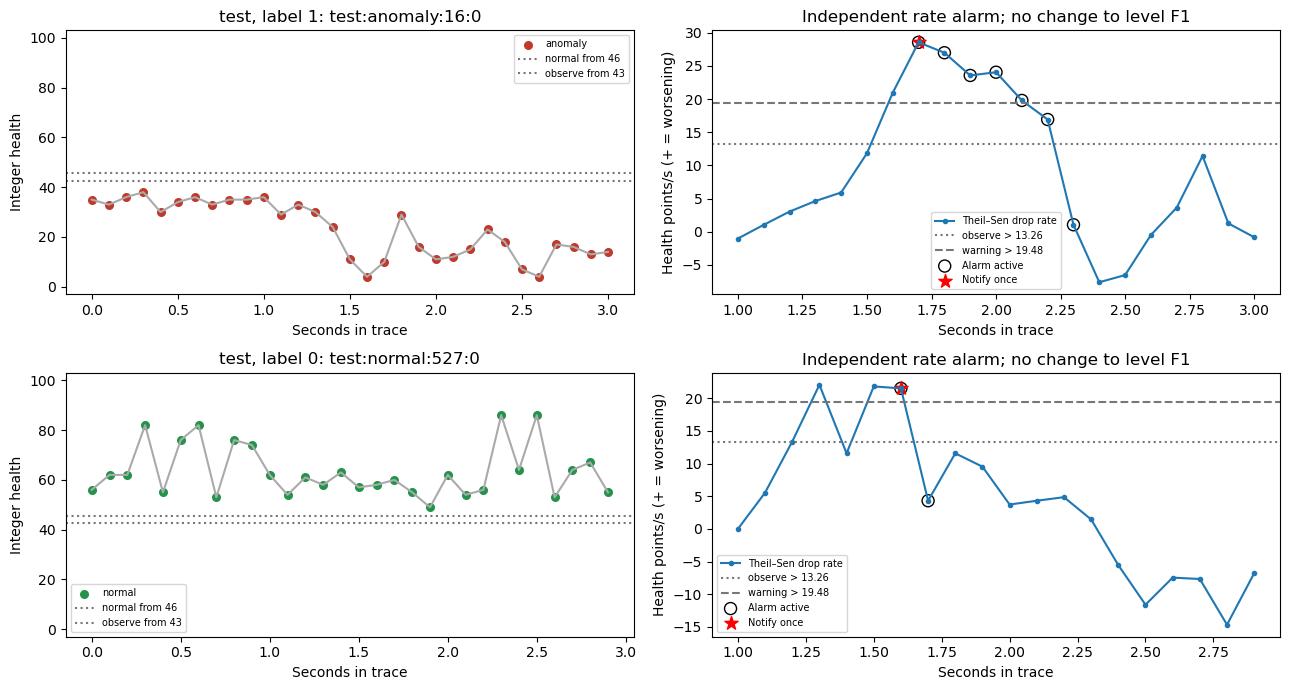

In [7]:
ANALYSIS_ID=datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
OUTPUT_BASE=Path(OUTPUT_ROOT).expanduser().resolve() if OUTPUT_ROOT else RUN_DIR/'threshold_health_analysis96'
OUT=OUTPUT_BASE/ANALYSIS_ID
if WRITE_OUTPUTS: (OUT/'figures').mkdir(parents=True,exist_ok=False)
FIGURES=[]
def show_figure(fig,name):
    fig.tight_layout()
    if WRITE_OUTPUTS: fig.savefig(OUT/'figures'/(name+'.png'),dpi=130,bbox_inches='tight')
    FIGURES.append(name);display(fig);plt.close(fig)

fig,axes=plt.subplots(1,2,figsize=(12,4))
grid=np.linspace(LOG_MIN,LOG_MAX,400);score_grid=np.maximum(10**grid-EPSILON,0)
axes[0].plot(score_grid,health_from_score(score_grid,LOG_MIN,LOG_MAX),color='#315c8a')
axes[0].set_xscale('log');axes[0].set(xlabel='Original score (log scale)',ylabel='Health (unrounded)',title='Same score, transformed display')
for role,color in [('observe','#d79415'),('anomaly','#c0392b')]:
    h=HEALTH_BOUNDS[role];boundary=W if role=='observe' else T
    axes[0].axvline(boundary,color=color,ls=':');axes[0].axhline(h,color=color,ls='--',label=f'{role}: H={h:.2f}, score={boundary:.6g}')
axes[0].legend(fontsize=8)
for s,color in [('normal','#23934b'),('observe','#d79415'),('anomaly','#c0392b')]:
    lo,hi=INTEGER_SPEC['ranges'][s]
    axes[1].barh(s,hi-lo+1,left=lo,color=color)
    axes[1].text((lo+hi)/2,s,f'{lo}–{hi}',ha='center',va='center',color='black',fontsize=10)
axes[1].set(xlim=(0,101),xlabel='Integer health shown to user',title='State-consistent integer display')
show_figure(fig,'score_to_health_and_integer_ranges')

fig,axes=plt.subplots(1,len(DATA),figsize=(6*len(DATA),4),squeeze=False)
for ax,(split,df) in zip(axes.ravel(),DATA.items()):
    for label,color in [(0,'#277cb5'),(1,'#c94f36')]:
        values=np.log10(df.loc[df.label_current.eq(label),'score']+EPSILON)
        ax.hist(values,bins=35,histtype='step',density=True,color=color,label=f'label {label}')
    for name,rule in RULES.items():ax.axvline(np.log10(rule['threshold']+EPSILON),ls='--',label=f"{name}: {rule['operator']} {rule['threshold']:.6g}")
    ax.set(title=split,xlabel='log10(original score + epsilon)',ylabel='Density');ax.legend(fontsize=8)
show_figure(fig,'original_score_distributions')

fig,axes=plt.subplots(1,len(DATA),figsize=(5*len(DATA),4),squeeze=False)
for ax,(split,df) in zip(axes.ravel(),DATA.items()):
    pred=predict_rule(df.score,RULES[ANOMALY_POLICY]);matrix=metrics.confusion_matrix(df[TARGET],pred,labels=[0,1])
    ax.imshow(matrix,cmap='Blues')
    for i in range(2):
        for j in range(2):ax.text(j,i,str(matrix[i,j]),ha='center',va='center',color='white' if matrix[i,j]>matrix.max()/2 else 'black')
    ax.set(xticks=[0,1],yticks=[0,1],xlabel='Prediction (original rule)',ylabel=TARGET,
           title=f"{split}: {ANOMALY_POLICY}, F1={binary_metrics(df[TARGET],pred)['F1']:.4f}")
show_figure(fig,'original_policy_confusion')

colors={'normal':'#23934b','observe':'#d79415','anomaly':'#c0392b'}
for split,g in WINDOWS.groupby('split',sort=False):
    choices=g.groupby(['label_current','trace_id']).agg(alarms=('warning_active','sum'),n=('window_id','size')).reset_index()
    choices=choices.sort_values(['alarms','n'],ascending=False).groupby('label_current',sort=True).head(1)
    fig,axes=plt.subplots(len(choices),2,figsize=(13,3.5*len(choices)),squeeze=False)
    for (_,choice),(ax,rate_ax) in zip(choices.iterrows(),axes):
        h=g[g.trace_id.eq(choice.trace_id)].sort_values('input_end_time')
        time=pd.to_datetime(h.input_end_time,utc=True);seconds=(time-time.iloc[0]).dt.total_seconds()
        ax.plot(seconds,h.hi_display_integer,color='#aaaaaa')
        for stage in colors:
            mask=h.hi_stage.eq(stage)
            if mask.any():ax.scatter(seconds[mask],h.loc[mask,'hi_display_integer'],color=colors[stage],s=30,label=stage)
        for name,bound in [('normal',INTEGER_SPEC['normal_min']),('observe',INTEGER_SPEC['observe_min'])]:
            ax.axhline(bound-.5,color='#777',ls=':',label=f'{name} from {bound}')
        ax.set(ylim=(-3,103),ylabel='Integer health',xlabel='Seconds in trace',title=f'{split}, label {choice.label_current}: {choice.trace_id}')
        ax.legend(fontsize=7)
        rate_ax.plot(seconds,h.hi_drop_rate,marker='o',ms=3,label='Theil–Sen drop rate')
        for key,ls in [('observe',':'),('warning','--')]:
            rule=RATE_BOUNDARIES[key]
            if rule['status']=='available':rate_ax.axhline(rule['boundary'],ls=ls,color='#777',label=f"{key} > {rule['boundary']:.2f}")
        mask=h.warning_active
        rate_ax.scatter(seconds[mask],h.loc[mask,'hi_drop_rate'],facecolors='none',edgecolors='black',s=75,label='Alarm active')
        mask=h.warning_notify
        rate_ax.scatter(seconds[mask],h.loc[mask,'hi_drop_rate'],marker='*',color='red',s=100,label='Notify once')
        rate_ax.set(xlabel='Seconds in trace',ylabel='Health points/s (+ = worsening)',title='Independent rate alarm; no change to level F1')
        rate_ax.legend(fontsize=7)
    show_figure(fig,'health_and_rate_'+split)

## 6. 추가 분석: Precision=Recall 이상 경계와 Q99·Q98·Q95 관찰 경계

이 절은 **저장된 모델의 Valid 점수로 경계를 계산하고, 같은 경계를 Valid/Test에 적용하는 실행 가능한 비교 분석**입니다. 위 절의 기본 정책(`valid_max_f1` 이상 + `normal_q99` 관찰)과 구분됩니다.

1. **이상 진입:** 선택 체크포인트의 저장 `pr_equal` 임계값을 읽고, Valid PR 곡선에서 Precision=Recall인 경계인지 검증합니다. PR 곡선의 판정은 `score >= threshold`입니다. 저장 정책의 `>`와 차이가 있으므로 아래 표에 두 연산자의 실제 성능과 경계 동점 수를 함께 표시합니다. **이번 비교에는 `>=`를 사용합니다.** Valid의 P=R이 Test에서도 성립한다는 뜻은 아닙니다.
2. **관찰 진입:** `label_current=0`인 정상 Valid 점수의 Q99/Q98/Q95를 `method='higher'`로 계산합니다. 이상이 우선이며, `관찰 경계 < score < 이상 경계`이면 관찰, `score <= 관찰 경계`이면 정상입니다. Q99는 저장 경계와 대조하며, Q98/Q95는 이 추가 분석에서 계산한 후보입니다. 모델 가중치가 분위수 자체를 학습한 것은 아닙니다.
3. **건강점수:** 앞 절과 동일한 Valid 기반 변환을 사용하고 각 후보의 경계를 정수 범위로 환산합니다. 상태는 원 score로 먼저 결정하며 정수 반올림으로 재판정하지 않습니다.
4. **급하락 알림:** 반올림 전 건강점수의 기울기와 정상 Valid 속도 기준을 그대로 사용합니다. 관찰 분위수와 독립적으로 계산하므로 정상 상태에서도 경고할 수 있습니다. 후보마다 상태 플래그를 바꿔 알림 정책을 다시 실행하고 경고가 같은지 검증합니다.

아래 개수는 **중첩된 윈도우 수**입니다. 관찰은 정답 라벨에 없는 운영 상태이므로 3-class F1은 계산하지 않습니다. `이상만 양성`과 `관찰+이상을 양성`으로 취급하는 이진 F1을 별도 표시합니다. 후자는 다른 판정 정책이며 고장 전조를 검증한 지표가 아닙니다.


In [8]:
def observation_quantile_comparison(valid, datasets, target, anomaly_threshold,
                                    quantiles=(.99, .98, .95)):
    """Fit observation cutoffs on normal Valid only; evaluate fixed cutoffs per split."""
    reference = valid.loc[valid.label_current.eq(0), 'score'].to_numpy(float)
    check(len(reference)>0 and np.isfinite(reference).all(), '정상 Valid 기준이 필요합니다.')
    threshold_rows, state_rows, metric_rows, segment_rows, window_frames = [], [], [], [], []
    for q in quantiles:
        check(0<q<1, '분위수는 0~1 사이여야 합니다.')
        cutoff = float(np.quantile(reference, q, method='higher'))
        check(cutoff<anomaly_threshold, '관찰 경계가 이상 경계 이상입니다: '+str(q))
        candidate = f'Q{q*100:g}'
        threshold_rows.append(dict(candidate=candidate, quantile=q, observe_threshold=cutoff,
                                   anomaly_threshold=anomaly_threshold))
        for split, source in datasets.items():
            frame = source[['window_id','source','segment','label_current',target,'score']].copy()
            frame = frame.loc[:, ~frame.columns.duplicated()]
            frame['split'] = split
            frame['candidate'] = candidate
            frame['anomaly_prediction'] = frame.score.ge(anomaly_threshold)
            frame['observe_prediction'] = frame.score.gt(cutoff)
            frame['hi_stage'] = np.select([frame.anomaly_prediction, frame.observe_prediction],
                                         ['anomaly','observe'], default='normal')
            y = frame[target].eq(1)
            observed = frame.hi_stage.eq('observe')
            state_rows.append(dict(split=split,candidate=candidate,total=len(frame),
                normal=int(frame.hi_stage.eq('normal').sum()),observe=int(observed.sum()),
                anomaly=int(frame.anomaly_prediction.sum()),
                normal_observe=int((~y & observed).sum()),anomaly_observe=int((y & observed).sum()),
                anomaly_normal=int((y & frame.hi_stage.eq('normal')).sum()),
                normal_total=int((~y).sum()),anomaly_total=int(y.sum()),
                normal_observe_pct=100*float(observed[~y].mean()),
                observe_or_anomaly_recall=100*float(frame.hi_stage[y].ne('normal').mean())))
            for evaluation, prediction in [('anomaly_only',frame.anomaly_prediction),
                                           ('observe_or_anomaly',frame.hi_stage.ne('normal'))]:
                metric_rows.append(dict(split=split,candidate=candidate,evaluation=evaluation,
                                        **binary_metrics(frame[target],prediction)))
            for label, group in frame.groupby(target):
                segments = group.groupby(['source','segment'],dropna=False).hi_stage.agg(
                    has_observe=lambda x:x.eq('observe').any(),
                    has_anomaly=lambda x:x.eq('anomaly').any())
                segment_rows.append(dict(split=split,candidate=candidate,label=int(label),
                    segments=len(segments),observe_segments=int(segments.has_observe.sum()),
                    anomaly_segments=int(segments.has_anomaly.sum()),
                    observe_segment_pct=100*float(segments.has_observe.mean())))
            window_frames.append(frame)
    return dict(thresholds=pd.DataFrame(threshold_rows),states=pd.DataFrame(state_rows),
                metrics=pd.DataFrame(metric_rows),segments=pd.DataFrame(segment_rows),
                windows=pd.concat(window_frames,ignore_index=True))

PR_SAVED_RULE = dict(POLICY_REGISTRY[CHECKPOINT_KEY]['policies']['pr_equal'])
check(PR_SAVED_RULE.get('threshold') is not None, '선택 체크포인트에 저장 P=R 경계가 없습니다.')
PR_THRESHOLD = float(PR_SAVED_RULE['threshold'])
pr_precision, pr_recall, pr_thresholds = metrics.precision_recall_curve(VALID[TARGET],VALID.score)
pr_equal_indices = np.flatnonzero(pr_precision[:-1] == pr_recall[:-1])
check(len(pr_equal_indices)>0, 'Valid에 정확한 P=R 지점이 없습니다. Test로 경계를 선택하지 않습니다.')
check(PR_THRESHOLD == float(pr_thresholds[pr_equal_indices[0]]), '저장 P=R 경계와 Valid 재계산 불일치')
PR_COMPARISON_RULE = dict(threshold=PR_THRESHOLD,operator='>=')
pr_replay_rows = []
for split, frame in DATA.items():
    for name, rule in [('stored_pr_equal',PR_SAVED_RULE),('PR_curve_comparator',PR_COMPARISON_RULE)]:
        pr_replay_rows.append(dict(split=split,policy=name,operator=rule['operator'],
            threshold=rule['threshold'],threshold_ties=int(frame.score.eq(PR_THRESHOLD).sum()),
            **binary_metrics(frame[TARGET],predict_rule(frame.score,rule))))
PR_REPLAY = pd.DataFrame(pr_replay_rows)
pr_valid = PR_REPLAY.query("split == 'valid' and policy == 'PR_curve_comparator'").iloc[0]
check(pr_valid.precision == pr_valid.recall, '>= 적용 후에도 Valid P=R 불일치')
print('6-A. 저장 연산자와 PR 곡선 연산자의 차이 (동점 포함 여부)')
display(PR_REPLAY)

COMPARISON = observation_quantile_comparison(VALID,DATA,TARGET,PR_THRESHOLD)
Q_THRESHOLDS = COMPARISON['thresholds']
Q_STATES = COMPARISON['states']
Q_METRICS = COMPARISON['metrics']
Q_SEGMENTS = COMPARISON['segments']
Q_WINDOWS = COMPARISON['windows']
check(float(Q_THRESHOLDS.iloc[0].observe_threshold) ==
      float(POLICY_REGISTRY[CHECKPOINT_KEY]['policies']['normal_q99']['threshold']),
      '재계산 Q99와 저장 Q99 불일치')
q_range_rows = []
for row in Q_THRESHOLDS.itertuples(index=False):
    bounds = dict(observe=float(health_from_score(row.observe_threshold,LOG_MIN,LOG_MAX)),
                  anomaly=float(health_from_score(PR_THRESHOLD,LOG_MIN,LOG_MAX)))
    integer_spec = hi_integer_display_spec(bounds)
    selected = Q_WINDOWS.candidate.eq(row.candidate)
    candidate_windows = Q_WINDOWS.loc[selected].copy()
    candidate_windows['health_index'] = health_from_score(candidate_windows.score,LOG_MIN,LOG_MAX).clip(0,100)
    Q_WINDOWS.loc[selected,'health_integer'] = integer_hi_scores(candidate_windows,integer_spec)
    q_range_rows.append(dict(candidate=row.candidate,observe_score=row.observe_threshold,
        anomaly_score=PR_THRESHOLD,observe_health=bounds['observe'],anomaly_health=bounds['anomaly'],
        **{s:f'{lo}~{hi}점' for s,(lo,hi) in integer_spec['ranges'].items()}))
Q_WINDOWS['health_integer'] = Q_WINDOWS.health_integer.astype(int)
Q_RANGES = pd.DataFrame(q_range_rows)
print('6-B. 실제 score 경계와 사용자에게 표시할 정수 범위')
display(Q_RANGES.rename(columns={'candidate':'관찰 기준','normal':'정상','observe':'관찰','anomaly':'이상'}))
print('6-C. 상태 개수: 동일한 P=R 이상 경계, 관찰 경계만 변경')
display(Q_STATES[['split','candidate','total','normal','observe','anomaly']].rename(
    columns={'candidate':'관찰 기준','total':'전체','normal':'정상','observe':'관찰','anomaly':'이상'}))
print('6-D. 관찰의 구성과 실제 이상인데 정상으로 표시되는 윈도우 수')
display(Q_STATES.drop(columns=['total','normal','observe','anomaly']).rename(columns={
    'candidate':'관찰 기준','normal_observe':'실제 정상→관찰','anomaly_observe':'실제 이상→관찰',
    'anomaly_normal':'실제 이상→정상','normal_total':'실제 정상 전체','anomaly_total':'실제 이상 전체',
    'normal_observe_pct':'정상 중 관찰 비율(%)','observe_or_anomaly_recall':'관찰+이상 재현율(%)'}))
print('6-E. 이진 성능 비교: anomaly_only의 F1은 Q 선택에 따라 변하지 않음')
display(Q_METRICS)
check(Q_METRICS.query("evaluation == 'anomaly_only'").groupby('split').F1.nunique().eq(1).all(),
      '관찰 기준 변경이 이상 판정을 바꿨습니다.')
print('6-F. 관찰이 한 번이라도 나타난 짧은 세그먼트 (고장 사건 수가 아님)')
display(Q_SEGMENTS)

# Re-run the existing rate policy with each candidate's state flags.
# Health transform, causal slope, Valid rate reference and rate configuration stay fixed.
q_alarm_rows = []
for candidate, candidate_windows in Q_WINDOWS.groupby('candidate',sort=False):
    flags = candidate_windows.set_index(['split','window_id'])
    rate_input = WINDOWS.copy()
    keys = pd.MultiIndex.from_frame(rate_input[['split','window_id']])
    for column in ['anomaly_prediction','observe_prediction']:
        rate_input[column] = flags.loc[keys,column].to_numpy()
    replay = apply_hi_rate_policy(rate_input,RATE_CONFIG)
    for column in ['warning_notify','warning_active','warning_cleared']:
        check(np.array_equal(replay[column],WINDOWS[column]), 'Q 변경으로 급하락 알림이 달라짐: '+column)
    for split, group in replay.groupby('split'):
        q_alarm_rows.append(dict(candidate=candidate,split=split,
            notifications=int(group.warning_notify.sum()),active_windows=int(group.warning_active.sum())))
Q_ALARMS = pd.DataFrame(q_alarm_rows)
print('6-G. 급하락 알림 재계산: 관찰 분위수와 독립 (정상에서도 가능)')
display(Q_ALARMS)


6-A. 저장 연산자와 PR 곡선 연산자의 차이 (동점 포함 여부)


,split,policy,operator,threshold,threshold_ties,TN,FP,FN,TP,precision,recall,F1
0,valid,stored_pr_equal,>,0.243237,1,979,6,7,95,0.940594,0.931373,0.935961
1,valid,PR_curve_comparator,>=,0.243237,1,978,7,7,95,0.931373,0.931373,0.931373
2,test,stored_pr_equal,>,0.243237,0,1970,18,8,166,0.902174,0.954023,0.927374
3,test,PR_curve_comparator,>=,0.243237,0,1970,18,8,166,0.902174,0.954023,0.927374


6-B. 실제 score 경계와 사용자에게 표시할 정수 범위


,관찰 기준,observe_score,anomaly_score,observe_health,anomaly_health,정상,관찰,이상
0,Q99,0.222636,0.243237,45.290478,44.663686,46~100점,45~45점,0~44점
1,Q98,0.170288,0.243237,47.188937,44.663686,48~100점,45~47점,0~44점
2,Q95,0.124976,0.243237,49.380059,44.663686,50~100점,45~49점,0~44점


6-C. 상태 개수: 동일한 P=R 이상 경계, 관찰 경계만 변경


...

,split,candidate,evaluation,TN,FP,FN,TP,precision,recall,F1
0,valid,Q99,anomaly_only,978,7,7,95,0.931373,0.931373,0.931373
1,valid,Q99,observe_or_anomaly,976,9,7,95,0.913462,0.931373,0.922330
2,test,Q99,anomaly_only,1970,18,8,166,0.902174,0.954023,0.927374
3,test,Q99,observe_or_anomaly,1965,23,8,166,0.878307,0.954023,0.914601
4,valid,Q98,anomaly_only,978,7,7,95,0.931373,0.931373,0.931373
5,valid,Q98,observe_or_anomaly,966,19,6,96,0.834783,0.941176,0.884793
6,test,Q98,anomaly_only,1970,18,8,166,0.902174,0.954023,0.927374
7,test,Q98,observe_or_anomaly,1940,48,7,167,0.776744,0.959770,0.858612
8,valid,Q95,anomaly_only,978,7,7,95,0.931373,0.931373,0.931373
9,valid,Q95,observe_or_anomaly,936,49,2,100,0.671141,0.980392,0.796813


6-F. 관찰이 한 번이라도 나타난 짧은 세그먼트 (고장 사건 수가 아님)


,split,candidate,label,segments,observe_segments,anomaly_segments,observe_segment_pct
0,valid,Q99,0,46,2,7,4.347826
1,valid,Q99,1,4,0,4,0.000000
2,test,Q99,0,90,4,9,4.444444
3,test,Q99,1,9,0,9,0.000000
4,valid,Q98,0,46,9,7,19.565217
5,valid,Q98,1,4,1,4,25.000000
6,test,Q98,0,90,26,9,28.888889
7,test,Q98,1,9,1,9,11.111111
8,valid,Q95,0,46,24,7,52.173913
9,valid,Q95,1,4,4,4,100.000000


6-G. 급하락 알림 재계산: 관찰 분위수와 독립 (정상에서도 가능)


,candidate,split,notifications,active_windows
0,Q99,test,4,15
1,Q99,valid,2,13
2,Q98,test,4,15
3,Q98,valid,2,13
4,Q95,test,4,15
5,Q95,valid,2,13


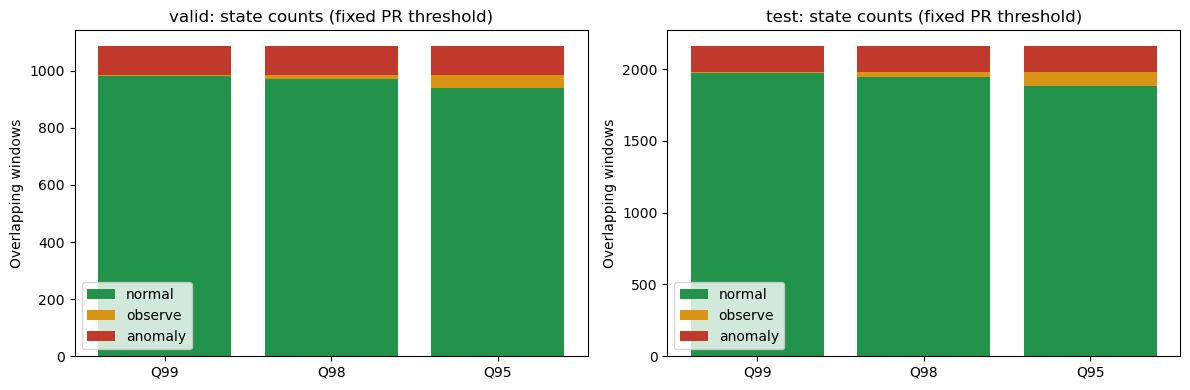

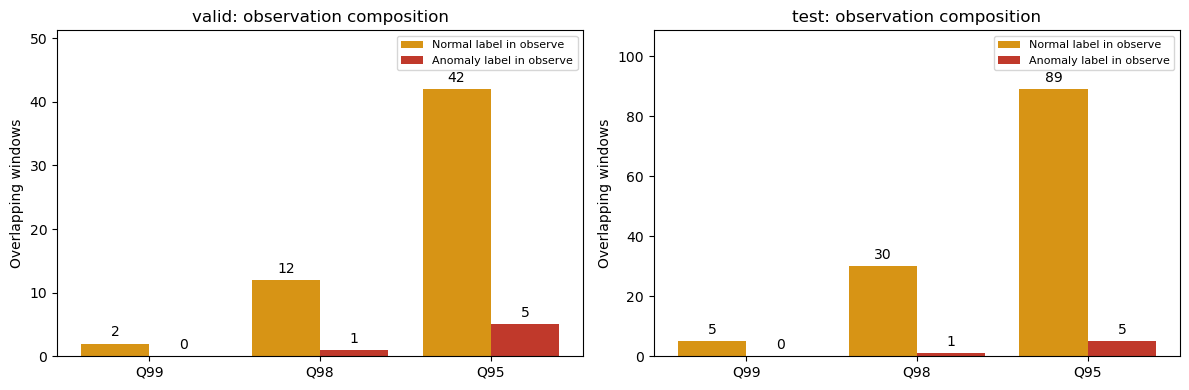

**VALID 결과 해석**

- **Q99**: 관찰 2개 (실제 정상 2개 / 실제 이상 0개). 정상 중 관찰 0.20%, 실제 이상→정상 7개. 정상 세그먼트 2/46개에서 관찰이 나타납니다.

- **Q98**: 관찰 13개 (실제 정상 12개 / 실제 이상 1개). 정상 중 관찰 1.22%, 실제 이상→정상 6개. 정상 세그먼트 9/46개에서 관찰이 나타납니다.

- **Q95**: 관찰 47개 (실제 정상 42개 / 실제 이상 5개). 정상 중 관찰 4.26%, 실제 이상→정상 2개. 정상 세그먼트 24/46개에서 관찰이 나타납니다.


세 후보 모두 이상 판정 F1은 **0.9314**입니다. 관찰까지 양성으로 묶으면 별도의 F1이 됩니다.

**TEST 결과 해석**

- **Q99**: 관찰 5개 (실제 정상 5개 / 실제 이상 0개). 정상 중 관찰 0.25%, 실제 이상→정상 8개. 정상 세그먼트 4/90개에서 관찰이 나타납니다.

- **Q98**: 관찰 31개 (실제 정상 30개 / 실제 이상 1개). 정상 중 관찰 1.51%, 실제 이상→정상 7개. 정상 세그먼트 26/90개에서 관찰이 나타납니다.

- **Q95**: 관찰 94개 (실제 정상 89개 / 실제 이상 5개). 정상 중 관찰 4.48%, 실제 이상→정상 3개. 정상 세그먼트 49/90개에서 관찰이 나타납니다.


세 후보 모두 이상 판정 F1은 **0.9274**입니다. 관찰까지 양성으로 묶으면 별도의 F1이 됩니다.

In [9]:
fig, axes = plt.subplots(1,len(DATA),figsize=(6*len(DATA),4),squeeze=False)
for ax, split in zip(axes.ravel(),DATA):
    table = Q_STATES[Q_STATES.split.eq(split)].set_index('candidate').loc[['Q99','Q98','Q95']]
    bottom = np.zeros(len(table))
    for state,color in [('normal','#23934b'),('observe','#d79415'),('anomaly','#c0392b')]:
        values = table[state].to_numpy()
        ax.bar(table.index,values,bottom=bottom,label=state,color=color)
        bottom += values
    ax.set(title=f'{split}: state counts (fixed PR threshold)',ylabel='Overlapping windows')
    ax.legend()
show_figure(fig,'comparison_pr_equal_state_counts')

fig, axes = plt.subplots(1,len(DATA),figsize=(6*len(DATA),4),squeeze=False)
for ax, split in zip(axes.ravel(),DATA):
    table = Q_STATES[Q_STATES.split.eq(split)].set_index('candidate').loc[['Q99','Q98','Q95']]
    positions = np.arange(len(table))
    for offset,column,label,color in [(-.2,'normal_observe','Normal label in observe','#d79415'),
                                     (.2,'anomaly_observe','Anomaly label in observe','#c0392b')]:
        bars = ax.bar(positions+offset,table[column],width=.4,label=label,color=color)
        ax.bar_label(bars,padding=3)
    ax.set_xticks(positions,table.index)
    ax.set(title=f'{split}: observation composition',ylabel='Overlapping windows')
    ax.margins(y=.22);ax.legend(fontsize=8)
show_figure(fig,'comparison_pr_equal_observation_composition')

# Generate the numerical interpretation from the freshly calculated tables.
for split in DATA:
    rows = Q_STATES[Q_STATES.split.eq(split)].set_index('candidate')
    segments = Q_SEGMENTS[Q_SEGMENTS.split.eq(split)&Q_SEGMENTS.label.eq(0)].set_index('candidate')
    lines = [f'**{split.upper()} 결과 해석**']
    for candidate in ['Q99','Q98','Q95']:
        r = rows.loc[candidate]; s = segments.loc[candidate]
        lines.append(f'- **{candidate}**: 관찰 {int(r["observe"])}개 '
            f'(실제 정상 {int(r.normal_observe)}개 / 실제 이상 {int(r.anomaly_observe)}개). '
            f'정상 중 관찰 {r.normal_observe_pct:.2f}%, 실제 이상→정상 {int(r.anomaly_normal)}개. '
            f'정상 세그먼트 {int(s.observe_segments)}/{int(s.segments)}개에서 관찰이 나타납니다.')
    f1 = Q_METRICS[(Q_METRICS.split.eq(split)) & Q_METRICS.evaluation.eq('anomaly_only')].F1.iloc[0]
    lines.append(f'\n세 후보 모두 이상 판정 F1은 **{f1:.4f}**입니다. 관찰까지 양성으로 묶으면 별도의 F1이 됩니다.')
    display(Markdown('\n\n'.join(lines)))


### 6-H. 추천과 해석의 범위

**현재 사용 목적에는 Q95를 우선 검토할 후보로 추천합니다.** 사용 목적은 정상·관찰·이상을 화면으로 구분하고, 가파른 악화에만 별도 경고를 내는 것입니다. 관찰 표시 자체가 출동이나 즉시 알림을 유발하지 않는다면 넓은 관찰 구간을 둘 수 있습니다. 위 코드의 `실제 이상→관찰`, `실제 이상→정상`을 보면 어느 정도 더 많은 이상 윈도우를 정상 표시에서 제외하는지 확인할 수 있습니다. 다만 이미 이상 라벨인 윈도우이므로 이를 **고장 전 조기 탐지 성공**이라고 해석하지 않습니다.

| 후보 | 현재 목적에서의 해석 | 선택 조건 |
|---|---|---|
| Q99 | 관찰 구간이 매우 좁아 중간 단계의 역할이 작음 | 관찰 표시를 최소화할 때 |
| Q98 | 관찰 범위와 정상 데이터의 관찰 부담 사이의 절충 후보 | 관찰마다 사람이 확인해야 할 때 |
| Q95 | 넓은 관찰 구간으로 변화 상황을 화면에 표시하기에 적합 | 관찰은 화면 표시, 실제 경고는 급하락 조건으로 제한할 때 |

**Q95가 논문에서 정한 보편적 최적값이라는 뜻은 아닙니다.** 복원 오차를 건강 지표로 바꾸는 근거는 [Malhotra et al. (2016)](https://arxiv.org/html/1608.06154)에서 찾을 수 있지만, 여기의 로그 변환·Valid 앵커·3단계 경계는 이 실험을 위한 설계입니다. [scikit-learn 임계값 조정 문서](https://scikit-learn.org/stable/modules/classification_threshold.html)는 모델 점수와 의사결정 경계를 구분하고 목적에 맞는 지표로 경계를 선택하도록 설명합니다. **P=R 역시 FP와 FN 개수가 같아지는 Valid 운영점일 뿐, 최대 F1이나 최소 비용을 보장하지 않습니다.**

관찰 비율은 실제 정상 윈도우 중 관찰로 표시된 비율입니다. 중첩 윈도우의 상관과 분위수 동점, 이상 우선 판정 때문에 명목상 1%·2%·5%와 정확히 같지 않습니다. 세그먼트 표는 반복 관찰 부담을 보완해서 보여주지만, 짧은 세그먼트 수를 독립 고장 사건 수로 취급할 수 없습니다. 정상→고장으로 이어지는 장기간 데이터가 없으므로 선행 경고 시간과 고장 사건별 탐지율은 아직 평가할 수 없습니다.

**모든 수치 경계는 Valid에서 계산했습니다.** 그러나 이미 확인한 Test 비교를 참고해 Q95를 추천했으므로 이 선택과 성능 해석은 탐색적입니다. 실제 적용 전에는 새로운 기간/설비 데이터에서 오경고 빈도, 경고 지속시간, 고장까지의 선행시간과 관찰 대응 비용으로 후보를 다시 검증해야 합니다. 이 절의 추천은 위 기본 정책을 자동으로 변경하지 않습니다.


## 7. 저장 및 근거

저장 내용: 원 score·원 예측·상태·정수 건강점수·알림(`windows.csv.gz`), 원 지표 재현표, 정책별 평가표, 정확한 경계와 HI 변환식, 기준 배열, 알림 사건, 출처 파일 SHA256, 그림. `score`의 의미와 `>`/`>=`를 반드시 함께 전달합니다.

| 근거 | 사용하는 부분 | 이 노트북에서 별도로 설계한 부분 |
|---|---|---|
| [Malhotra 외, 2016, §4.3 식 (7)](https://arxiv.org/html/1608.06154) | 정상 모델의 복원오차를 낮을수록 좋은 HI로 변환 | 윈도우 마지막 시점 score의 로그 변환·전체 Valid 범위 고정. 원문의 수명 궤적별 HI/RUL을 재현하지 않음 |
| [scikit-learn, Decision threshold tuning](https://scikit-learn.org/stable/modules/classification_threshold.html) | 점수 생성 모델과 의사결정 임계값 분리, 검증 자료로 경계 선택 | 새 최적화를 하지 않고 원 프로젝트의 저장 경계·연산자·F1을 재현 |
| [Sen 1968](https://doi.org/10.1080/01621459.1968.10480934), [SciPy 공식 설명](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.theilslopes.html) | 시점 쌍 기울기의 중앙값인 Theil–Sen 추정 | 1초·tail 1%/5%·연속 2회·경고 해제는 탐색적 운영 설정 |

단조 변환 후에도 **원 score로 동일한 판정을 수행**하므로 예측과 F1이 보존됩니다. 단순히 HI를 정수로 자른 뒤 경계와 비교하면 이 보장은 깨질 수 있습니다. 관찰까지 양성으로 합치거나 급하락까지 합친 F1은 다른 정책의 성능이며 표에서 분리했습니다.

원 Valid는 가중치 선택에도 사용되어 독립 보정 자료가 아니고 Test는 이미 열람되었습니다. 저장 지표와 일치한다는 것은 재현성 검증이며 새 데이터 일반화의 증명이 아닙니다. 관측 구간과 독립 고장 사건도 동일하지 않습니다. 실제 운용 경계·전조 성능의 최종 검증에는 새로운 날짜·운전조건의 연속 데이터가 필요합니다.

추가 분석도 `comparison_*.csv`, `comparison_windows.csv.gz`, `comparison_rules.json` 및 비교 그림으로 저장합니다. 기본 정책 산출물과 파일명을 구분합니다.

In [10]:
def clean(value):
    if isinstance(value,dict):return {str(k):clean(v) for k,v in value.items()}
    if isinstance(value,(list,tuple)):return [clean(v) for v in value]
    if isinstance(value,np.generic):value=value.item()
    if isinstance(value,float) and not np.isfinite(value):return None
    return value

EXPORT_RULES=dict(version=ALGORITHM_VERSION, checkpoint=SELECTED_INFO['checkpoint'],epoch=SELECTED_INFO['epoch'],
    logical_checkpoint=CHECKPOINT_KEY, evaluation_target=TARGET, score_column='score',score_description=description,
    score_definition=SCORE_DEFINITIONS['valid'], anomaly_policy=ANOMALY_POLICY,observe_policy=OBSERVE_POLICY,
    policies=RULES, health_formula='100*(log_max-log10(score+epsilon))/(log_max-log_min)',
    log_min=float(LOG_MIN),log_max=float(LOG_MAX),epsilon=EPSILON,health_boundaries=HEALTH_BOUNDS,
    integer_display=INTEGER_SPEC, rate_config=RATE_CONFIG, rate_boundaries=RATE_BOUNDARIES,
    rate_reference_n=len(rate_reference),rate_reference_available=RATE_AVAILABLE,
    decision_source='original score with saved threshold and operator; no health rounding or rate overrides',
    calibration_source='Valid only; already used for model selection',
    rate_policy_status='exploratory; not the threshold learned/selected by the original model',
    rate_level_gate_enabled=RATE_CONFIG['level_gate_tail']<1,
    model_retrained=False,model_reinferred=False,test_used_for_fitting=False)
if WRITE_OUTPUTS:
    for name,obj in [('rules.json',EXPORT_RULES),('provenance.json',dict(analysis_id=ANALYSIS_ID,
        source_run=str(RUN_DIR),input_hashes={str(p.relative_to(RUN_DIR)):sha256(p) for p in INPUT_FILES},
        python=platform.python_version(),numpy=np.__version__,pandas=pd.__version__,
        scope='Saved evaluation replay only; previously inspected Test is exploratory',figures=FIGURES))]:
        (OUT/name).write_text(json.dumps(clean(obj),ensure_ascii=False,indent=2,allow_nan=False),encoding='utf-8')
    for name,df in [('reproduction.csv',REPRODUCTION),('health_policy_metrics.csv',HEALTH_METRICS),
                    ('boundaries.csv',BOUNDARY_TABLE),('integer_ranges.csv',DISPLAY_RANGES),
                    ('state_summary.csv',STATE_SUMMARY),('alarm_summary.csv',ALARM_SUMMARY),('alarm_events.csv',EVENTS)]:
        df.to_csv(OUT/name,index=False)
    comparison_rules = dict(
        status='exploratory comparison; default policy unchanged',
        checkpoint=SELECTED_INFO['checkpoint'],epoch=SELECTED_INFO['epoch'],target=TARGET,
        stored_pr_equal=PR_SAVED_RULE,comparison_anomaly_rule=PR_COMPARISON_RULE,
        operator_override_reason='precision_recall_curve uses >=, including threshold ties',
        observe_operator='>',quantile_method='higher',reference='label_current=0 in Valid',
        thresholds=Q_THRESHOLDS.to_dict('records'),health_log_min=float(LOG_MIN),health_log_max=float(LOG_MAX),
        rate_policy='same unrounded health/slope/reference; independently replayed for each Q',
        recommendation='Q95 for display-only observation; Q98 if observation triggers manual action',
        test_used_for_threshold_fitting=False,recommendation_after_test_inspection=True)
    (OUT/'comparison_rules.json').write_text(
        json.dumps(clean(comparison_rules),ensure_ascii=False,indent=2,allow_nan=False),encoding='utf-8')
    for name, frame in [('pr_comparators',PR_REPLAY),('thresholds',Q_THRESHOLDS),('integer_ranges',Q_RANGES),
                        ('states',Q_STATES),('metrics',Q_METRICS),('segments',Q_SEGMENTS),('alarms',Q_ALARMS)]:
        frame.to_csv(OUT/('comparison_'+name+'.csv'),index=False)
    Q_WINDOWS.to_csv(OUT/'comparison_windows.csv.gz',index=False,compression='gzip')
    WINDOWS.to_csv(OUT/'windows.csv.gz',index=False,compression='gzip')
    np.savez_compressed(OUT/'reference.npz',normal_valid_score=normal_reference,normal_valid_drop_rate=rate_reference)
    print('저장 완료:',OUT)
print('원 예측 불일치 수:',int(REPRODUCTION.prediction_mismatches.sum()))
print('원 F1과 최대 차이:',float(REPRODUCTION.F1_difference.abs().max()))
print('사용자 안내 범위:',dict(zip(DISPLAY_RANGES.state_name,DISPLAY_RANGES.user_range)))

저장 완료: [OUTPUT_DIRECTORY]
원 예측 불일치 수: 0
원 F1과 최대 차이: 0.0
사용자 안내 범위: {'정상': '46~100점', '관찰': '43~45점', '이상': '0~42점'}


## 8. Q95 추천안으로 사용자에게 전달되는 실제 예시

여기의 **Q95는 95번 노트북이 아니라 정상 Valid 점수의 95백분위 관찰 경계**입니다. 6절의 P=R 이상 경계(`>=`)와 결합합니다. 기본 정책의 `user_readout`을 재사용하지 않고, Q95 상태와 정수 범위로 안내 문구를 다시 생성합니다.

현재 선택 실험의 표시 범위는 정상 50~100점, 관찰 45~49점, 이상 0~44점입니다. 아래 코드는 경계에서 범위를 다시 계산합니다. 건강점수는 고장 확률이나 잔여 수명 비율이 아닙니다. 기울기는 반올림 전 건강점수로 계산하며, 급하락 조건이 연속 충족될 때만 새 경고를 보냅니다. 이상 상태 자체는 화면 표시이며, 여기서는 별도 푸시 경고를 발생시키지 않습니다.

Test가 있으면 Test에서 대표 사례를 우선 선택하며, 없는 경우 Valid 사례임을 표시합니다. 해당 상황이 실제 데이터에 없으면 없다고 출력합니다. 아래 예시는 대표 동작 확인용이며 빈도나 정확도를 나타내지 않습니다. 사용자 안내와 분석용 정답 라벨·원 score는 별도 표로 표시합니다.


In [11]:
Q95_THRESHOLD = float(Q_THRESHOLDS.set_index('candidate').loc['Q95','observe_threshold'])
Q95_BOUNDS = dict(observe=float(health_from_score(Q95_THRESHOLD,LOG_MIN,LOG_MAX)),
                  anomaly=float(health_from_score(PR_THRESHOLD,LOG_MIN,LOG_MAX)))
Q95_INTEGER_SPEC = hi_integer_display_spec(Q95_BOUNDS)
Q95_USER_WINDOWS = WINDOWS.copy()
Q95_USER_WINDOWS['anomaly_prediction'] = predict_rule(Q95_USER_WINDOWS.score,PR_COMPARISON_RULE)
Q95_USER_WINDOWS['observe_prediction'] = Q95_USER_WINDOWS.score.gt(Q95_THRESHOLD)
Q95_USER_WINDOWS = apply_hi_rate_policy(Q95_USER_WINDOWS,RATE_CONFIG)
if not RATE_AVAILABLE:
    Q95_USER_WINDOWS['rate_status'] = 'reference_unavailable'
Q95_USER_WINDOWS['hi_display_integer'] = integer_hi_scores(Q95_USER_WINDOWS,Q95_INTEGER_SPEC)
check(np.array_equal(Q95_USER_WINDOWS.warning_notify,WINDOWS.warning_notify), 'Q95 알림 독립성 확인 실패')

def q95_user_message(row, integer_spec):
    names={'normal':'정상','observe':'관찰','anomaly':'이상'}
    lo,hi=integer_spec['ranges'][row.hi_stage]
    text=f'건강 {int(row.hi_display_integer)}점 | {names[row.hi_stage]} ({lo}~{hi}점)'
    if row.rate_status=='evaluated':
        speed=abs(float(row.hi_drop_rate))
        direction='하락' if row.hi_drop_rate>0 else '회복' if row.hi_drop_rate<0 else '변화'
        shown='1점/초 미만' if 0<speed<.5 else f'약 {int(np.floor(speed+.5))}점/초'
        text+=f' | 건강점수 {direction} {shown}'
    else:
        text+=' | 변화 속도 '+('기준 부족' if row.rate_status=='reference_unavailable' else '계산 대기')
    if row.warning_notify:
        text+=' | 새 경고: 건강점수가 급격히 하락했습니다. 설비 상태를 확인하세요.'
    elif row.warning_active:
        text+=' | 급하락 경고 '+('해제 확인 중' if row.warning_clear_pending else '유지 중')
    elif row.warning_cleared:
        text+=' | '+('급하락 경고 해제' if row.warning_clear_reason=='release_confirmed'
                     else '이력 부족으로 경고 판단 중단')
    elif row.trend_attention:
        text+=' | 하락 추세 관찰 (새 경고 없음)'
    else:
        text+=' | 새 경고 없음'
    return text

Q95_USER_WINDOWS['user_readout'] = Q95_USER_WINDOWS.apply(q95_user_message,axis=1,integer_spec=Q95_INTEGER_SPEC)
print('Q95 사용자 안내 범위:',Q95_INTEGER_SPEC['ranges'])
cases=[('정상 상태',Q95_USER_WINDOWS.hi_stage.eq('normal') & ~Q95_USER_WINDOWS.warning_active & Q95_USER_WINDOWS.rate_available),
       ('관찰 상태',Q95_USER_WINDOWS.hi_stage.eq('observe') & ~Q95_USER_WINDOWS.warning_active),
       ('이상 상태',Q95_USER_WINDOWS.hi_stage.eq('anomaly') & ~Q95_USER_WINDOWS.warning_active),
       ('정상이어도 급하락 새 경고',Q95_USER_WINDOWS.hi_stage.eq('normal') & Q95_USER_WINDOWS.warning_notify),
       ('관찰 중 급하락 새 경고',Q95_USER_WINDOWS.hi_stage.eq('observe') & Q95_USER_WINDOWS.warning_notify),
       ('이상 중 급하락 새 경고',Q95_USER_WINDOWS.hi_stage.eq('anomaly') & Q95_USER_WINDOWS.warning_notify),
       ('경고 유지',Q95_USER_WINDOWS.warning_active & ~Q95_USER_WINDOWS.warning_notify & ~Q95_USER_WINDOWS.warning_clear_pending),
       ('경고 해제',Q95_USER_WINDOWS.warning_cleared & Q95_USER_WINDOWS.warning_clear_reason.eq('release_confirmed')),
       ('속도 이력 부족',~Q95_USER_WINDOWS.rate_available)]
selected=[]; missing=[]
for case,mask in cases:
    candidates=Q95_USER_WINDOWS.loc[mask].copy()
    if candidates.empty:
        missing.append(case);continue
    candidates['_priority']=np.where(candidates.split.eq('test'),0,1)
    row=candidates.sort_values(['_priority','input_end_time','window_id']).iloc[0].drop('_priority')
    row['example_case']=case
    selected.append(row)
Q95_EXAMPLES=pd.DataFrame(selected).reset_index(drop=True)
for row in Q95_EXAMPLES.itertuples(index=False):
    print(f'[{row.example_case}] ({row.split})\n{row.user_readout}\n')
if missing: print('실제 데이터에 없는 예시 (생성하지 않음):',', '.join(missing))
print('분석용 추적 표: 사용자 화면에는 정답 라벨과 원 score를 표시하지 않습니다.')
display(Q95_EXAMPLES[['example_case','split','window_id','input_end_time',TARGET,'score',
                      'hi_display_integer','hi_drop_rate','warning_notify','warning_active','user_readout']])

# Show an actual causal sequence, including history before the first new warning.
notified=Q95_USER_WINDOWS[Q95_USER_WINDOWS.warning_notify].copy()
if len(notified):
    notified['_priority']=np.where(notified.split.eq('test'),0,1)
    event=notified.sort_values(['_priority','input_end_time']).iloc[0]
    Q95_TIMELINE=Q95_USER_WINDOWS[Q95_USER_WINDOWS.trace_id.eq(event.trace_id)].sort_values('input_end_time').copy()
    print('실제 한 구간의 안내 변화 (반복 푸시는 warning_notify=True인 시점에만 전송)')
    display(Q95_TIMELINE[['input_end_time','hi_display_integer','hi_stage','warning_notify','user_readout']])
else:
    Q95_TIMELINE=Q95_USER_WINDOWS.iloc[:0].copy()
    print('새 경고가 발생한 실제 구간이 없습니다.')
if WRITE_OUTPUTS:
    Q95_EXAMPLES.to_csv(OUT/'q95_user_examples.csv',index=False,encoding='utf-8-sig')
    Q95_TIMELINE.to_csv(OUT/'q95_user_timeline.csv',index=False,encoding='utf-8-sig')
    Q95_USER_WINDOWS.to_csv(OUT/'q95_user_windows.csv.gz',index=False,compression='gzip')
    (OUT/'q95_user_examples_missing.json').write_text(json.dumps(missing,ensure_ascii=False,indent=2),encoding='utf-8')
    print('Q95 사용자 안내 예시 저장 완료:',OUT)


Q95 사용자 안내 범위: {'normal': [50, 100], 'observe': [45, 49], 'anomaly': [0, 44]}
[정상 상태] (test)
건강 57점 | 정상 (50~100점) | 건강점수 회복 약 2점/초 | 새 경고 없음

[관찰 상태] (test)
건강 47점 | 관찰 (45~49점) | 변화 속도 계산 대기 | 새 경고 없음

[이상 상태] (test)
건강 43점 | 이상 (0~44점) | 건강점수 하락 약 3점/초 | 새 경고 없음

[정상이어도 급하락 새 경고] (test)
건강 53점 | 정상 (50~100점) | 건강점수 하락 약 28점/초 | 새 경고: 건강점수가 급격히 하락했습니다. 설비 상태를 확인하세요.

[관찰 중 급하락 새 경고] (valid)
건강 47점 | 관찰 (45~49점) | 건강점수 하락 약 26점/초 | 새 경고: 건강점수가 급격히 하락했습니다. 설비 상태를 확인하세요.

[이상 중 급하락 새 경고] (test)
건강 20점 | 이상 (0~44점) | 건강점수 하락 약 23점/초 | 새 경고: 건강점수가 급격히 하락했습니다. 설비 상태를 확인하세요.

[경고 유지] (test)
건강 14점 | 이상 (0~44점) | 건강점수 하락 약 24점/초 | 급하락 경고 유지 중

[경고 해제] (test)
건강 55점 | 정상 (50~100점) | 건강점수 하락 약 12점/초 | 급하락 경고 해제

[속도 이력 부족] (test)
건강 66점 | 정상 (50~100점) | 변화 속도 계산 대기 | 새 경고 없음

분석용 추적 표: 사용자 화면에는 정답 라벨과 원 score를 표시하지 않습니다.


,example_case,split,window_id,input_end_time,label_10s,score,hi_display_integer,hi_drop_rate,warning_notify,warning_active,user_readout
0,정상 상태,test,normal:482:16020:16039,2022-07-12 01:01:07.424,0,0.045306,57,-1.648972,False,False,건강 57점 | 정상 (50~100점) | 건강점수 회복 약 2점/초 | 새 경고 없음
1,관찰 상태,test,normal:482:16011:16030,2022-07-12 01:01:06.524,0,0.165582,47,NaN,False,False,건강 47점 | 관찰 (45~49점) | 변화 속도 계산 대기 | 새 경고 없음
2,이상 상태,test,normal:492:16385:16404,2022-07-12 01:02:37.480,0,0.299470,43,3.212980,False,False,건강 43점 | 이상 (0~44점) | 건강점수 하락 약 3점/초 | 새 경고 없음
3,정상이어도 급하락 새 경고,test,normal:494:16482:16501,2022-07-12 01:02:51.971,0,0.070475,53,28.451639,True,True,건강 53점 | 정상 (50~100점) | 건강점수 하락 약 28점/초 | 새 경고...
4,관찰 중 급하락 새 경고,valid,normal:462:15294:15313,2022-07-12 00:58:27.993,0,0.180625,47,25.879090,True,True,건강 47점 | 관찰 (45~49점) | 건강점수 하락 약 26점/초 | 새 경고:...
5,이상 중 급하락 새 경고,test,anomaly:12:306:325,2022-07-17 10:52:42.672,1,8.279089,20,22.841606,True,True,건강 20점 | 이상 (0~44점) | 건강점수 하락 약 23점/초 | 새 경고: ...
6,경고 유지,test,anomaly:12:307:326,2022-07-17 10:52:42.772,1,18.324181,14,23.570307,False,True,건강 14점 | 이상 (0~44점) | 건강점수 하락 약 24점/초 | 급하락 경고...
7,경고 해제,test,normal:527:17618:17637,2022-07-12 01:07:24.967,0,0.053124,55,11.576194,False,False,건강 55점 | 정상 (50~100점) | 건강점수 하락 약 12점/초 | 급하락 ...
8,속도 이력 부족,test,normal:482:16010:16029,2022-07-12 01:01:06.424,0,0.012055,66,NaN,False,False,건강 66점 | 정상 (50~100점) | 변화 속도 계산 대기 | 새 경고 없음


실제 한 구간의 안내 변화 (반복 푸시는 warning_notify=True인 시점에만 전송)


,input_end_time,hi_display_integer,hi_stage,warning_notify,user_readout
1323,2022-07-12 01:02:50.071,74,normal,False,건강 74점 | 정상 (50~100점) | 변화 속도 계산 대기 | 새 경고 없음
1324,2022-07-12 01:02:50.171,45,observe,False,건강 45점 | 관찰 (45~49점) | 변화 속도 계산 대기 | 새 경고 없음
1325,2022-07-12 01:02:50.271,83,normal,False,건강 83점 | 정상 (50~100점) | 변화 속도 계산 대기 | 새 경고 없음
1326,2022-07-12 01:02:50.371,67,normal,False,건강 67점 | 정상 (50~100점) | 변화 속도 계산 대기 | 새 경고 없음
1327,2022-07-12 01:02:50.471,66,normal,False,건강 66점 | 정상 (50~100점) | 변화 속도 계산 대기 | 새 경고 없음
1328,2022-07-12 01:02:50.571,48,observe,False,건강 48점 | 관찰 (45~49점) | 변화 속도 계산 대기 | 새 경고 없음
1329,2022-07-12 01:02:50.671,71,normal,False,건강 71점 | 정상 (50~100점) | 변화 속도 계산 대기 | 새 경고 없음
1330,2022-07-12 01:02:50.771,53,normal,False,건강 53점 | 정상 (50~100점) | 변화 속도 계산 대기 | 새 경고 없음
1331,2022-07-12 01:02:50.871,55,normal,False,건강 55점 | 정상 (50~100점) | 변화 속도 계산 대기 | 새 경고 없음
1332,2022-07-12 01:02:50.971,81,normal,False,건강 81점 | 정상 (50~100점) | 변화 속도 계산 대기 | 새 경고 없음


Q95 사용자 안내 예시 저장 완료: [OUTPUT_DIRECTORY]
